In [1]:
import os

print("Current Folder:")
print(os.getcwd())

Current Folder:
C:\Users\Pralisha Tripathy\Desktop\AuditIQ\notebooks


In [2]:
import os

print(os.listdir("../data/raw"))

['Procument Invoice Fraud Dataset v1']


In [7]:
import pandas as pd
import os

print(os.listdir("../data/raw"))

C:\Users\Pralisha Tripathy\AppData\Roaming\Python\Python39\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\Pralisha Tripathy\AppData\Roaming\Python\Python39\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


['Procument Invoice Fraud Dataset v1']


In [8]:
import os

print(os.listdir("../data/raw/Procument Invoice Fraud Dataset v1"))

['behavioural_features.parquet', 'departments.parquet', 'images', 'images_metadata.parquet', 'invoices.parquet', 'labels.parquet', 'manifest.json', 'splits.parquet', 'suppliers.parquet']


In [9]:
!pip install pyarrow

In [10]:
import pandas as pd

base_path = "../data/raw/Procument Invoice Fraud Dataset v1/"

invoices = pd.read_parquet(base_path + "invoices.parquet")
suppliers = pd.read_parquet(base_path + "suppliers.parquet")
departments = pd.read_parquet(base_path + "departments.parquet")
behaviour = pd.read_parquet(base_path + "behavioural_features.parquet")
labels = pd.read_parquet(base_path + "labels.parquet")

In [11]:
datasets = {
    "Invoices": invoices,
    "Suppliers": suppliers,
    "Departments": departments,
    "Behaviour": behaviour,
    "Labels": labels
}

for name, df in datasets.items():
    print(f"\n{name}")
    print("-" * 40)
    print("Shape:", df.shape)
    print("Columns:")
    print(df.columns.tolist())


Invoices
----------------------------------------
Shape: (300000, 10)
Columns:
['invoice_id', 'supplier_id', 'department_id', 'invoice_date', 'invoice_amount', 'currency', 'payment_terms', 'invoice_type', 'submission_hour', 'image_path']

Suppliers
----------------------------------------
Shape: (2000, 6)
Columns:
['supplier_id', 'supplier_country', 'supplier_age_days', 'supplier_risk_score', 'blacklisted_flag', 'avg_invoice_amount']

Departments
----------------------------------------
Shape: (50, 3)
Columns:
['department_id', 'region', 'annual_budget']

Behaviour
----------------------------------------
Shape: (300000, 7)
Columns:
['invoice_id', 'supplier_invoice_count_30d', 'supplier_avg_amount_90d', 'invoice_amount_zscore', 'duplicate_invoice_flag', 'split_invoice_flag', 'late_night_submission_flag']

Labels
----------------------------------------
Shape: (300000, 5)
Columns:
['invoice_id', 'is_fraud', 'fraud_type', 'fraud_tags', 'explanations']


In [12]:
master_df = (
    invoices
    .merge(suppliers, on="supplier_id", how="left")
    .merge(departments, on="department_id", how="left")
    .merge(behaviour, on="invoice_id", how="left")
    .merge(labels, on="invoice_id", how="left")
)

print("Master Dataset Shape:", master_df.shape)

Master Dataset Shape: (300000, 27)


In [13]:
master_df.head()

,invoice_id,supplier_id,department_id,invoice_date,invoice_amount,currency,payment_terms,invoice_type,submission_hour,image_path,...,supplier_invoice_count_30d,supplier_avg_amount_90d,invoice_amount_zscore,duplicate_invoice_flag,split_invoice_flag,late_night_submission_flag,is_fraud,fraud_type,fraud_tags,explanations
0,INV_0000000,7316ce64-2a14-4a96-9b0c-62eb27c8fc6c,DPT_025,2023-04-18,3565.57,ZAR,NET60,GOODS,18,data/v1/20251214_172643/images/INV_0000000.png,...,13.0,5417.982105,-0.453822,0,0,0,0,NONE,,"{""reason"": ""NONE""}"
1,INV_0000001,7428a656-b3ee-4d3b-9a10-412954aebd1b,DPT_010,2023-10-08,9871.78,ZAR,NET30,SERVICES,6,None,...,6.0,6745.242333,0.261806,0,0,0,0,NONE,,"{""reason"": ""NONE""}"
2,INV_0000002,7b0ccad9-eee1-4cae-b02e-21aa352b6ec8,DPT_041,2023-09-24,8530.64,ZAR,NET60,SERVICES,23,None,...,13.0,4950.948095,0.109614,0,0,0,0,NONE,,"{""reason"": ""NONE""}"
3,INV_0000003,1c6345ab-6e0e-41e8-985d-3f861d2324e6,DPT_015,2023-10-15,1378.52,ZAR,NET30,GOODS,7,None,...,15.0,3524.075116,-0.702008,0,1,0,1,SPLIT,SPLIT,"{""rules"": [""SPLIT""]}"
4,INV_0000004,22d839d3-33e4-4986-b18c-ccdc131eb723,DPT_039,2023-06-07,2373.66,ZAR,NET30,GOODS,12,None,...,11.0,4670.320968,-0.589080,0,0,0,0,NONE,,"{""reason"": ""NONE""}"


In [14]:
master_df["is_fraud"].value_counts()

is_fraud
0    233590
1     66410
Name: count, dtype: int64

In [15]:
master_df["is_fraud"].value_counts(normalize=True) * 100

is_fraud
0    77.863333
1    22.136667
Name: proportion, dtype: float64

In [16]:
master_df.isnull().sum().sort_values(ascending=False)

image_path                    255000
invoice_id                         0
avg_invoice_amount                 0
fraud_tags                         0
fraud_type                         0
is_fraud                           0
late_night_submission_flag         0
split_invoice_flag                 0
duplicate_invoice_flag             0
invoice_amount_zscore              0
supplier_avg_amount_90d            0
supplier_invoice_count_30d         0
annual_budget                      0
region                             0
blacklisted_flag                   0
supplier_id                        0
supplier_risk_score                0
supplier_age_days                  0
supplier_country                   0
submission_hour                    0
invoice_type                       0
payment_terms                      0
currency                           0
invoice_amount                     0
invoice_date                       0
department_id                      0
explanations                       0
d

In [17]:
master_df.isnull().sum().sort_values(ascending=False).head(15)

image_path                    255000
invoice_id                         0
avg_invoice_amount                 0
fraud_tags                         0
fraud_type                         0
is_fraud                           0
late_night_submission_flag         0
split_invoice_flag                 0
duplicate_invoice_flag             0
invoice_amount_zscore              0
supplier_avg_amount_90d            0
supplier_invoice_count_30d         0
annual_budget                      0
region                             0
blacklisted_flag                   0
dtype: int64

In [18]:
audit_df = master_df.drop(
    columns=[
        "image_path",
        "fraud_tags",
        "explanations"
    ]
)

print(audit_df.shape)

(300000, 24)


In [19]:
audit_df.head()

,invoice_id,supplier_id,department_id,invoice_date,invoice_amount,currency,payment_terms,invoice_type,submission_hour,supplier_country,...,region,annual_budget,supplier_invoice_count_30d,supplier_avg_amount_90d,invoice_amount_zscore,duplicate_invoice_flag,split_invoice_flag,late_night_submission_flag,is_fraud,fraud_type
0,INV_0000000,7316ce64-2a14-4a96-9b0c-62eb27c8fc6c,DPT_025,2023-04-18,3565.57,ZAR,NET60,GOODS,18,CA,...,North Carolina,2.171350e+07,13.0,5417.982105,-0.453822,0,0,0,0,NONE
1,INV_0000001,7428a656-b3ee-4d3b-9a10-412954aebd1b,DPT_010,2023-10-08,9871.78,ZAR,NET30,SERVICES,6,SV,...,Arizona,4.778807e+08,6.0,6745.242333,0.261806,0,0,0,0,NONE
2,INV_0000002,7b0ccad9-eee1-4cae-b02e-21aa352b6ec8,DPT_041,2023-09-24,8530.64,ZAR,NET60,SERVICES,23,MR,...,Connecticut,5.119035e+07,13.0,4950.948095,0.109614,0,0,0,0,NONE
3,INV_0000003,1c6345ab-6e0e-41e8-985d-3f861d2324e6,DPT_015,2023-10-15,1378.52,ZAR,NET30,GOODS,7,SR,...,Pennsylvania,7.018474e+06,15.0,3524.075116,-0.702008,0,1,0,1,SPLIT
4,INV_0000004,22d839d3-33e4-4986-b18c-ccdc131eb723,DPT_039,2023-06-07,2373.66,ZAR,NET30,GOODS,12,TV,...,Louisiana,2.118290e+08,11.0,4670.320968,-0.589080,0,0,0,0,NONE


In [20]:
#Objective: Quantify how much an invoice deviates from the supplier's normal invoice pattern.

audit_df["invoice_supplier_ratio"] = (
    audit_df["invoice_amount"] /
    audit_df["avg_invoice_amount"]
)

audit_df["invoice_supplier_ratio"].describe()

count    300000.000000
mean          1.197162
std           0.789146
min           0.052420
25%           0.668186
50%           0.999237
75%           1.498384
max          14.177652
Name: invoice_supplier_ratio, dtype: float64

In [21]:
audit_df[[
    "invoice_amount",
    "avg_invoice_amount",
    "invoice_supplier_ratio"
]].head()

,invoice_amount,avg_invoice_amount,invoice_supplier_ratio
0,3565.57,4552.54,0.783205
1,9871.78,5568.13,1.772908
2,8530.64,4542.37,1.878015
3,1378.52,2705.89,0.509452
4,2373.66,3590.46,0.661102


In [22]:
audit_df["invoice_supplier_ratio"].describe()

count    300000.000000
mean          1.197162
std           0.789146
min           0.052420
25%           0.668186
50%           0.999237
75%           1.498384
max          14.177652
Name: invoice_supplier_ratio, dtype: float64

In [23]:
# Section 6: Measure invoice significance relative to department budget.

audit_df["budget_impact_ratio"] = (
    audit_df["invoice_amount"] /
    audit_df["annual_budget"]
)

audit_df["budget_impact_ratio"].describe()

count    3.000000e+05
mean     9.313738e-05
std      2.788431e-04
min      1.636288e-07
25%      1.190298e-05
50%      2.693173e-05
75%      7.077325e-05
max      3.084448e-02
Name: budget_impact_ratio, dtype: float64

In [24]:
# Inspect sample values of the new budget impact feature.

audit_df[[
    "invoice_amount",
    "annual_budget",
    "budget_impact_ratio"
]].head()

,invoice_amount,annual_budget,budget_impact_ratio
0,3565.57,2.171350e+07,0.000164
1,9871.78,4.778807e+08,0.000021
2,8530.64,5.119035e+07,0.000167
3,1378.52,7.018474e+06,0.000196
4,2373.66,2.118290e+08,0.000011


In [25]:
# Section 7: Aggregate control exceptions into a single audit risk indicator.

audit_df["control_exception_count"] = (
    audit_df["duplicate_invoice_flag"] +
    audit_df["split_invoice_flag"] +
    audit_df["late_night_submission_flag"]
)

audit_df["control_exception_count"].value_counts().sort_index()

control_exception_count
0    192825
1     96437
2     10738
Name: count, dtype: int64

In [26]:
# Inspect the distribution of control exception counts.

audit_df["control_exception_count"].describe()

count    300000.000000
mean          0.393043
std           0.556909
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           2.000000
Name: control_exception_count, dtype: float64

In [27]:
# Section 8: Assess supplier risk exposure using existing supplier risk intelligence.

audit_df["supplier_risk_category"] = pd.cut(
    audit_df["supplier_risk_score"],
    bins=[0, 33, 66, 100],
    labels=[
        "Low Risk Supplier",
        "Moderate Risk Supplier",
        "High Risk Supplier"
    ]
)

audit_df["supplier_risk_category"].value_counts()

supplier_risk_category
Low Risk Supplier         300000
Moderate Risk Supplier         0
High Risk Supplier             0
Name: count, dtype: int64

In [28]:
# Review supplier risk distribution.

audit_df["supplier_risk_score"].describe()

count    300000.000000
mean          0.286945
std           0.153719
min           0.002000
25%           0.168000
50%           0.269000
75%           0.392000
max           0.861000
Name: supplier_risk_score, dtype: float64

In [29]:
# Inspect minimum and maximum supplier risk scores.

print("Min:", audit_df["supplier_risk_score"].min())
print("Max:", audit_df["supplier_risk_score"].max())

Min: 0.002
Max: 0.861


In [30]:
# Review a few supplier risk score values.

audit_df["supplier_risk_score"].head(10)

0    0.219
1    0.083
2    0.198
3    0.382
4    0.139
5    0.185
6    0.396
7    0.425
8    0.171
9    0.451
Name: supplier_risk_score, dtype: float64

In [31]:
# Section 8: Classify suppliers into third-party risk tiers.

audit_df["supplier_risk_tier"] = pd.cut(
    audit_df["supplier_risk_score"],
    bins=[0, 0.33, 0.66, 1.0],
    labels=[
        "Low Risk",
        "Moderate Risk",
        "High Risk"
    ]
)

audit_df["supplier_risk_tier"].value_counts()

supplier_risk_tier
Low Risk         193936
Moderate Risk    101710
High Risk          4354
Name: count, dtype: int64

In [32]:
# Section 9: Flag invoices involving high-risk third-party suppliers.

audit_df["high_risk_supplier_flag"] = (
    audit_df["supplier_risk_tier"] == "High Risk"
).astype(int)

audit_df["high_risk_supplier_flag"].value_counts()

high_risk_supplier_flag
0    295646
1      4354
Name: count, dtype: int64

In [33]:
# Section 10: Compare fraud incidence across high-risk and non-high-risk suppliers.

pd.crosstab(
    audit_df["high_risk_supplier_flag"],
    audit_df["is_fraud"],
    normalize="index"
) * 100

is_fraud,0,1
high_risk_supplier_flag,,
0,78.137367,21.862633
1,59.255857,40.744143


In [34]:
# Section 11: Assess fraud incidence across control exception populations.

pd.crosstab(
    audit_df["control_exception_count"],
    audit_df["is_fraud"],
    normalize="index"
) * 100

is_fraud,0,1
control_exception_count,,
0,91.166602,8.833398
1,59.700115,40.299885
2,2.095362,97.904638


## Risk Indicator Assessment

### Third-Party Risk Exposure

High-Risk Suppliers:
Fraud Rate = 40.74%

Other Suppliers:
Fraud Rate = 21.86%

Conclusion:
Validated as a significant procurement fraud risk indicator.

---

### Control Exception Exposure

0 Exceptions:
Fraud Rate = 8.83%

1 Exception:
Fraud Rate = 40.30%

2 Exceptions:
Fraud Rate = 97.90%

Conclusion:
Control exception activity represents the strongest identified fraud signal within the dataset.

In [35]:
# Section 12: Review all available columns before model preparation.

audit_df.columns.tolist()

['invoice_id',
 'supplier_id',
 'department_id',
 'invoice_date',
 'invoice_amount',
 'currency',
 'payment_terms',
 'invoice_type',
 'submission_hour',
 'supplier_country',
 'supplier_age_days',
 'supplier_risk_score',
 'blacklisted_flag',
 'avg_invoice_amount',
 'region',
 'annual_budget',
 'supplier_invoice_count_30d',
 'supplier_avg_amount_90d',
 'invoice_amount_zscore',
 'duplicate_invoice_flag',
 'split_invoice_flag',
 'late_night_submission_flag',
 'is_fraud',
 'fraud_type',
 'invoice_supplier_ratio',
 'budget_impact_ratio',
 'control_exception_count',
 'supplier_risk_category',
 'supplier_risk_tier',
 'high_risk_supplier_flag']

In [36]:
# Section 13: Define modelling features and target variable.

target = "is_fraud"

feature_columns = [
    "invoice_amount",
    "currency",
    "payment_terms",
    "invoice_type",
    "submission_hour",
    "supplier_country",
    "supplier_age_days",
    "supplier_risk_score",
    "blacklisted_flag",
    "region",
    "annual_budget",
    "supplier_invoice_count_30d",
    "supplier_avg_amount_90d",
    "invoice_amount_zscore",
    "duplicate_invoice_flag",
    "split_invoice_flag",
    "late_night_submission_flag",
    "invoice_supplier_ratio",
    "budget_impact_ratio",
    "control_exception_count",
    "supplier_risk_tier",
    "high_risk_supplier_flag"
]

X = audit_df[feature_columns]
y = audit_df[target]

print("Feature Count:", len(feature_columns))
print("Dataset Shape:", X.shape)

Feature Count: 22
Dataset Shape: (300000, 22)


In [37]:
# Section 14: Define categorical business attributes for CatBoost.

categorical_features = [
    "currency",
    "payment_terms",
    "invoice_type",
    "supplier_country",
    "region",
    "supplier_risk_tier"
]

print("Categorical Features:")
print(categorical_features)

print("\nCount:", len(categorical_features))

Categorical Features:
['currency', 'payment_terms', 'invoice_type', 'supplier_country', 'region', 'supplier_risk_tier']

Count: 6


In [38]:
# Section 14A: Create reporting directories for audit analytics outputs.

from pathlib import Path

BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

(Path(BASE_DIR / "outputs" / "eda" / "figures")).mkdir(parents=True, exist_ok=True)
(Path(BASE_DIR / "outputs" / "eda" / "tables")).mkdir(parents=True, exist_ok=True)

print("AuditIQ reporting directories created.")

AuditIQ reporting directories created.


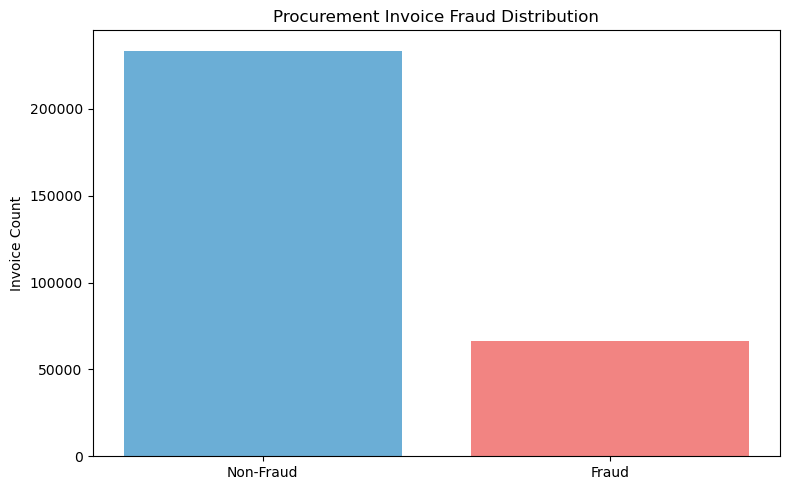

In [39]:
# Section 15: Analyze fraud prevalence within the procurement population.

import matplotlib.pyplot as plt

fraud_summary = (
    audit_df["is_fraud"]
    .value_counts()
    .rename_axis("Fraud Status")
    .reset_index(name="Invoice Count")
)

fraud_summary.to_csv(
    BASE_DIR / "outputs" / "eda" / "tables" / "fraud_distribution.csv",
    index=False
)

plt.figure(figsize=(8,5))

plt.bar(
    ["Non-Fraud", "Fraud"],
    fraud_summary["Invoice Count"],
    color=["#6BAED6", "#F28482"]
)

plt.title("Procurement Invoice Fraud Distribution")
plt.ylabel("Invoice Count")

plt.tight_layout()

plt.savefig(
    BASE_DIR / "outputs" / "eda" / "figures" / "01_fraud_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

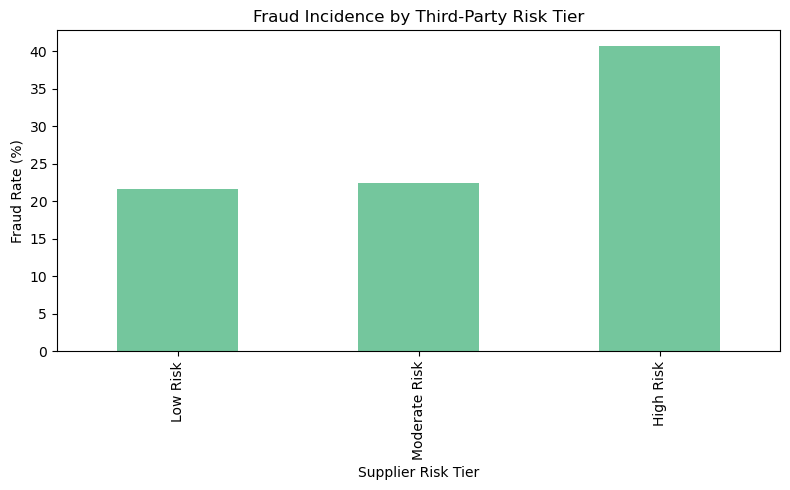

In [40]:
# Section 16: Assess fraud incidence across Third-Party Risk Tiers.

import pandas as pd
import matplotlib.pyplot as plt

supplier_risk_analysis = (
    pd.crosstab(
        audit_df["supplier_risk_tier"],
        audit_df["is_fraud"],
        normalize="index"
    ) * 100
)

supplier_risk_analysis.to_csv(
    BASE_DIR / "outputs" / "eda" / "tables" / "supplier_risk_tier_analysis.csv"
)

supplier_risk_analysis[1].plot(
    kind="bar",
    figsize=(8,5),
    color="#74C69D"
)

plt.title("Fraud Incidence by Third-Party Risk Tier")
plt.ylabel("Fraud Rate (%)")
plt.xlabel("Supplier Risk Tier")

plt.tight_layout()

plt.savefig(
    BASE_DIR / "outputs" / "eda" / "figures" / "02_supplier_risk_tier_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

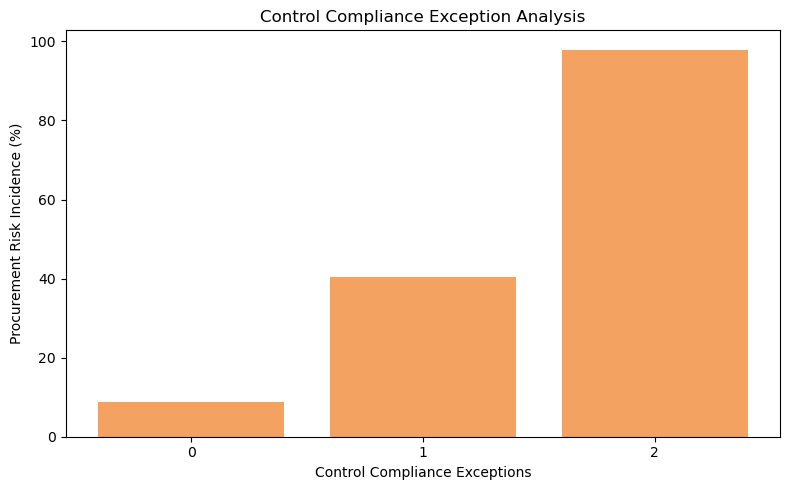

In [41]:
# Section 17: Assess procurement risk exposure across control compliance exception populations.

control_exception_analysis = (
    pd.crosstab(
        audit_df["control_exception_count"],
        audit_df["is_fraud"],
        normalize="index"
    ) * 100
)

control_exception_analysis.to_csv(
    BASE_DIR / "outputs" / "eda" / "tables" / "control_compliance_exception_analysis.csv"
)

plt.figure(figsize=(8,5))

plt.bar(
    control_exception_analysis.index.astype(str),
    control_exception_analysis[1],
    color="#F4A261"
)

plt.title("Control Compliance Exception Analysis")
plt.xlabel("Control Compliance Exceptions")
plt.ylabel("Procurement Risk Incidence (%)")

plt.tight_layout()

plt.savefig(
    BASE_DIR / "outputs" / "eda" / "figures" / "03_control_compliance_exception_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [42]:
# Section 18: Assess elevated procurement risk concentration across third-party supplier tiers.

third_party_risk_concentration = (
    audit_df
    .groupby("supplier_risk_tier")
    .agg(
        total_invoices=("invoice_id", "count"),
        fraud_cases=("is_fraud", "sum"),
        fraud_rate=("is_fraud", "mean")
    )
    .reset_index()
)

third_party_risk_concentration["fraud_rate"] = (
    third_party_risk_concentration["fraud_rate"] * 100
)

third_party_risk_concentration.to_csv(
    BASE_DIR / "outputs" / "eda" / "tables" / "third_party_risk_concentration.csv",
    index=False
)

third_party_risk_concentration

C:\Users\Pralisha Tripathy\AppData\Local\Temp\ipykernel_14740\408231403.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  audit_df


,supplier_risk_tier,total_invoices,fraud_cases,fraud_rate
0,Low Risk,193936,41857,21.582893
1,Moderate Risk,101710,22779,22.396028
2,High Risk,4354,1774,40.744143


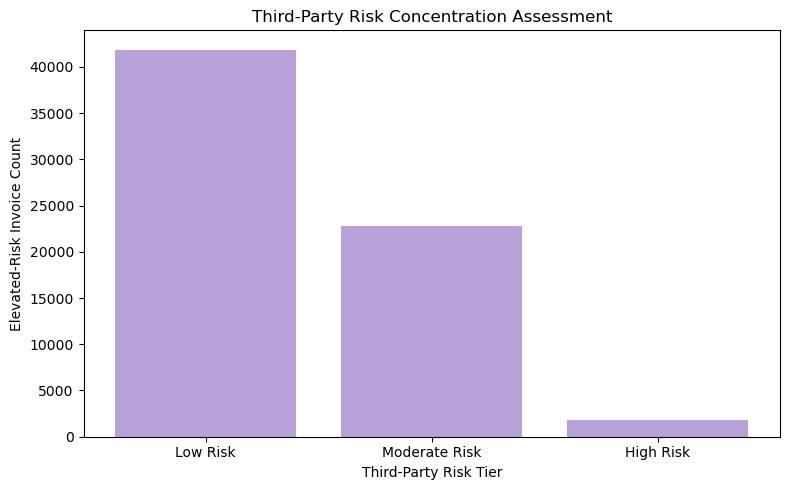

In [43]:
# Visualize elevated procurement risk concentration by third-party risk tier.

plt.figure(figsize=(8,5))

plt.bar(
    third_party_risk_concentration["supplier_risk_tier"].astype(str),
    third_party_risk_concentration["fraud_cases"],
    color="#B8A1D9"
)

plt.title("Third-Party Risk Concentration Assessment")
plt.xlabel("Third-Party Risk Tier")
plt.ylabel("Elevated-Risk Invoice Count")

plt.tight_layout()

plt.savefig(
    BASE_DIR / "outputs" / "eda" / "figures" / "04_third_party_risk_concentration_assessment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

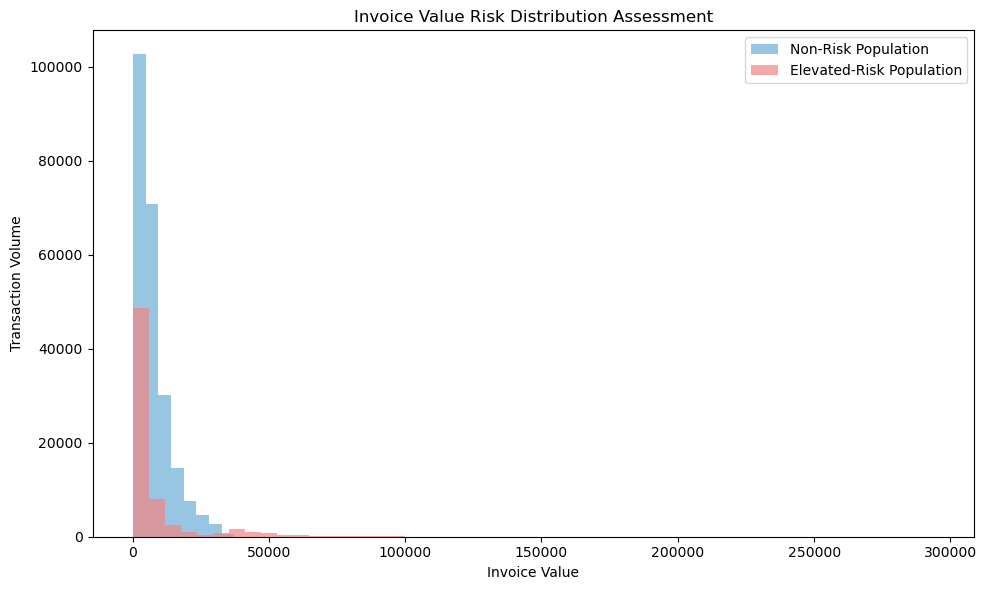

In [44]:
# Section 19: Analyze invoice value distribution across risk outcomes.

plt.figure(figsize=(10,6))

audit_df[audit_df["is_fraud"] == 0]["invoice_amount"].plot(
    kind="hist",
    bins=50,
    alpha=0.7,
    color="#6BAED6",
    label="Non-Risk Population"
)

audit_df[audit_df["is_fraud"] == 1]["invoice_amount"].plot(
    kind="hist",
    bins=50,
    alpha=0.7,
    color="#F28482",
    label="Elevated-Risk Population"
)

plt.title("Invoice Value Risk Distribution Assessment")
plt.xlabel("Invoice Value")
plt.ylabel("Transaction Volume")
plt.legend()

plt.tight_layout()

plt.savefig(
    BASE_DIR / "outputs" / "eda" / "figures" / "05_invoice_value_risk_distribution_assessment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [45]:
# Section 19: Export invoice value summary statistics by risk population.

invoice_value_summary = (
    audit_df
    .groupby("is_fraud")["invoice_amount"]
    .describe()
)

invoice_value_summary.to_csv(
    BASE_DIR / "outputs" / "eda" / "tables" / "invoice_value_risk_summary.csv"
)

invoice_value_summary

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,233590.0,7427.770754,6230.531271,142.04,3113.0625,5452.505,9652.8050,232806.17
1,66410.0,8046.373192,14627.172706,37.35,1554.9225,2925.380,6347.4975,294048.72


In [46]:
# Section 20: Assess procurement risk concentration across operating regions.

regional_risk_analysis = (
    audit_df
    .groupby("region")
    .agg(
        total_invoices=("invoice_id", "count"),
        fraud_cases=("is_fraud", "sum"),
        fraud_rate=("is_fraud", "mean")
    )
    .reset_index()
)

regional_risk_analysis["fraud_rate"] = (
    regional_risk_analysis["fraud_rate"] * 100
)

regional_risk_analysis = regional_risk_analysis.sort_values(
    "fraud_rate",
    ascending=False
)

regional_risk_analysis.to_csv(
    BASE_DIR / "outputs" / "eda" / "tables" / "regional_risk_concentration_assessment.csv",
    index=False
)

regional_risk_analysis.head(15)

,region,total_invoices,fraud_cases,fraud_rate
20,Tennessee,18017,4072,22.600877
5,Hawaii,5911,1334,22.568093
23,Wyoming,12134,2733,22.523488
17,Oregon,6079,1369,22.520151
18,Pennsylvania,11791,2655,22.517174
2,California,6066,1357,22.370590
6,Louisiana,18126,4037,22.271875
11,Nevada,18058,4021,22.267139
8,Michigan,12060,2682,22.238806
3,Connecticut,29939,6647,22.201810


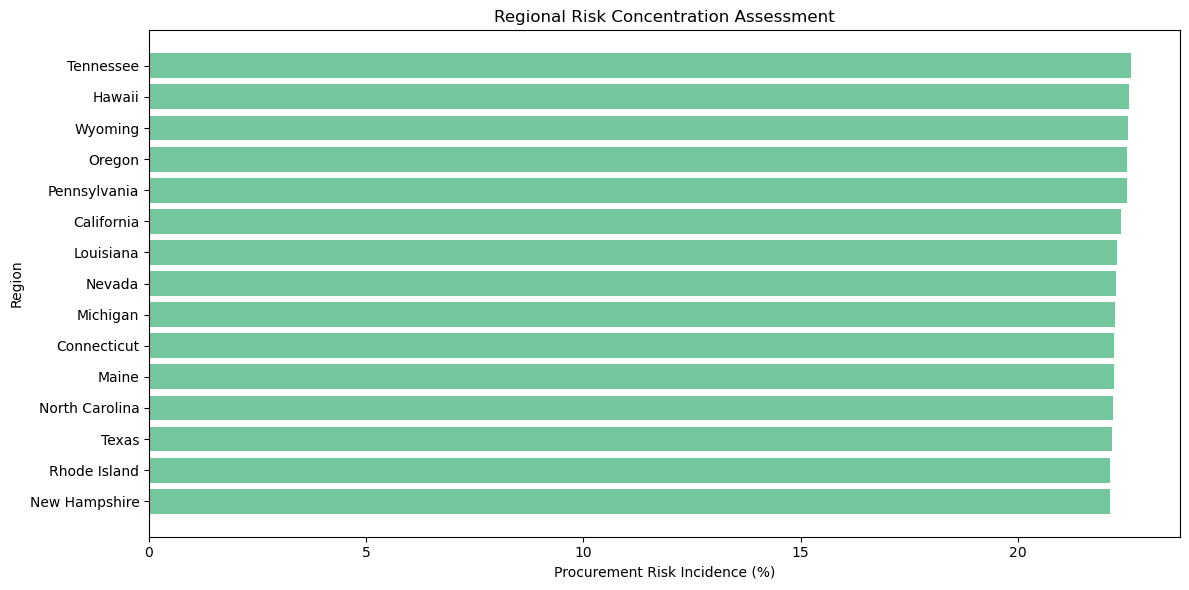

In [47]:
# Section 20: Visualize regions with the highest procurement risk exposure.

top_regions = regional_risk_analysis.head(15)

plt.figure(figsize=(12,6))

plt.barh(
    top_regions["region"],
    top_regions["fraud_rate"],
    color="#74C69D"
)

plt.title("Regional Risk Concentration Assessment")
plt.xlabel("Procurement Risk Incidence (%)")
plt.ylabel("Region")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    BASE_DIR / "outputs" / "eda" / "figures" / "06_regional_risk_concentration_assessment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [48]:
# Section 21: Assess procurement risk exposure across invoice classifications.

invoice_category_analysis = (
    audit_df
    .groupby("invoice_type")
    .agg(
        total_invoices=("invoice_id", "count"),
        risk_cases=("is_fraud", "sum"),
        risk_incidence=("is_fraud", "mean")
    )
    .reset_index()
)

invoice_category_analysis["risk_incidence"] = (
    invoice_category_analysis["risk_incidence"] * 100
)

invoice_category_analysis = invoice_category_analysis.sort_values(
    "risk_incidence",
    ascending=False
)

invoice_category_analysis.to_csv(
    BASE_DIR / "outputs" / "eda" / "tables" / "invoice_category_risk_assessment.csv",
    index=False
)

invoice_category_analysis

,invoice_type,total_invoices,risk_cases,risk_incidence
0,GOODS,164863,36599,22.199645
1,SERVICES,135137,29811,22.059836


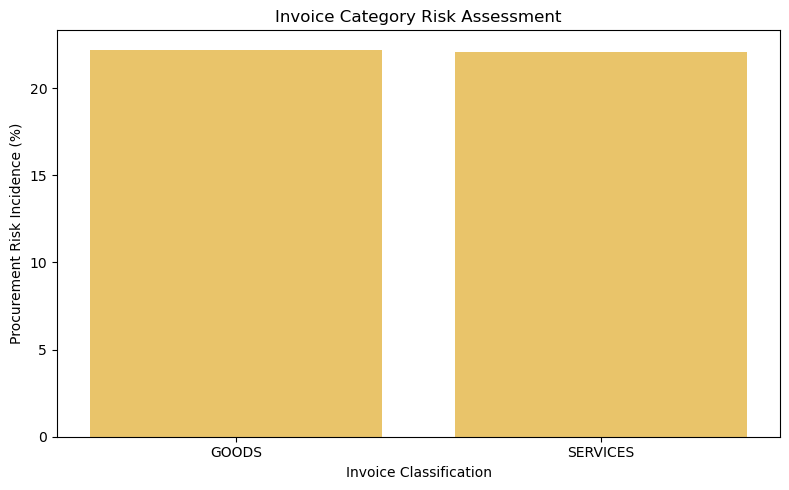

In [49]:
# Section 21: Visualize procurement risk exposure by invoice classification.

plt.figure(figsize=(8,5))

plt.bar(
    invoice_category_analysis["invoice_type"],
    invoice_category_analysis["risk_incidence"],
    color="#E9C46A"
)

plt.title("Invoice Category Risk Assessment")
plt.xlabel("Invoice Classification")
plt.ylabel("Procurement Risk Incidence (%)")

plt.tight_layout()

plt.savefig(
    BASE_DIR / "outputs" / "eda" / "figures" / "07_invoice_category_risk_assessment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [50]:
# Section 22: Generate risk intelligence correlation assessment.

risk_indicator_columns = [
    "invoice_amount",
    "supplier_risk_score",
    "supplier_invoice_count_30d",
    "invoice_amount_zscore",
    "invoice_supplier_ratio",
    "budget_impact_ratio",
    "control_exception_count",
    "high_risk_supplier_flag",
    "is_fraud"
]

correlation_matrix = (
    audit_df[risk_indicator_columns]
    .corr()
)

correlation_matrix.to_csv(
    BASE_DIR / "outputs" / "eda" / "tables" / "risk_indicator_correlation_matrix.csv"
)

correlation_matrix

,invoice_amount,supplier_risk_score,supplier_invoice_count_30d,invoice_amount_zscore,invoice_supplier_ratio,budget_impact_ratio,control_exception_count,high_risk_supplier_flag,is_fraud
invoice_amount,1.000000,0.000801,-0.003111,1.000000,0.566975,0.381616,-0.144585,0.018100,0.029144
supplier_risk_score,0.000801,1.000000,0.000685,0.000801,-0.002198,0.002031,-0.000106,0.346370,0.035177
supplier_invoice_count_30d,-0.003111,0.000685,1.000000,-0.003111,-0.002341,-0.000626,0.020039,0.005571,0.027912
invoice_amount_zscore,1.000000,0.000801,-0.003111,1.000000,0.566975,0.381616,-0.144585,0.018100,0.029144
invoice_supplier_ratio,0.566975,-0.002198,-0.002341,0.566975,1.000000,0.214388,-0.254394,-0.000676,-0.219936
budget_impact_ratio,0.381616,0.002031,-0.000626,0.381616,0.214388,1.000000,-0.057271,0.005137,0.009453
control_exception_count,-0.144585,-0.000106,0.020039,-0.144585,-0.254394,-0.057271,1.000000,0.001286,0.487119
high_risk_supplier_flag,0.018100,0.346370,0.005571,0.018100,-0.000676,0.005137,0.001286,1.000000,0.054391
is_fraud,0.029144,0.035177,0.027912,0.029144,-0.219936,0.009453,0.487119,0.054391,1.000000


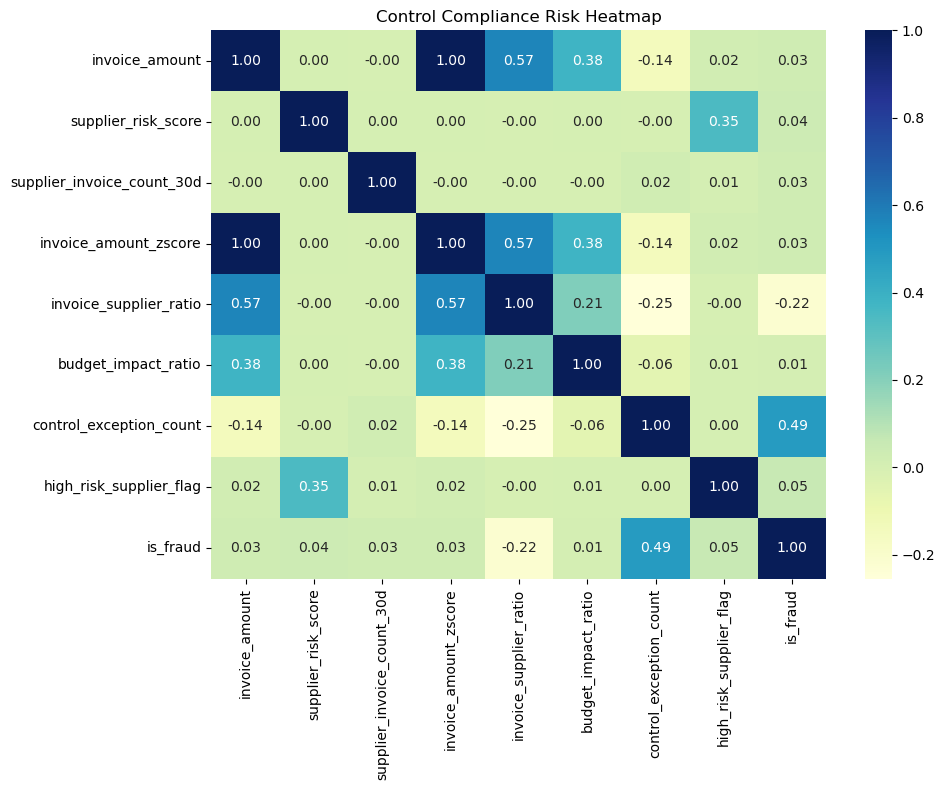

In [51]:
# Section 22: Visualize relationships among procurement risk indicators.

import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Control Compliance Risk Heatmap")

plt.tight_layout()

plt.savefig(
    BASE_DIR / "outputs" / "eda" / "figures" / "08_control_compliance_risk_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [53]:
# Section 23: Prepare the final modelling dataset for the Risk Intelligence Engine.

model_df = audit_df.copy()

print("Model Dataset Shape:", model_df.shape)

model_df.head()

Model Dataset Shape: (300000, 30)


,invoice_id,supplier_id,department_id,invoice_date,invoice_amount,currency,payment_terms,invoice_type,submission_hour,supplier_country,...,split_invoice_flag,late_night_submission_flag,is_fraud,fraud_type,invoice_supplier_ratio,budget_impact_ratio,control_exception_count,supplier_risk_category,supplier_risk_tier,high_risk_supplier_flag
0,INV_0000000,7316ce64-2a14-4a96-9b0c-62eb27c8fc6c,DPT_025,2023-04-18,3565.57,ZAR,NET60,GOODS,18,CA,...,0,0,0,NONE,0.783205,0.000164,0,Low Risk Supplier,Low Risk,0
1,INV_0000001,7428a656-b3ee-4d3b-9a10-412954aebd1b,DPT_010,2023-10-08,9871.78,ZAR,NET30,SERVICES,6,SV,...,0,0,0,NONE,1.772908,0.000021,0,Low Risk Supplier,Low Risk,0
2,INV_0000002,7b0ccad9-eee1-4cae-b02e-21aa352b6ec8,DPT_041,2023-09-24,8530.64,ZAR,NET60,SERVICES,23,MR,...,0,0,0,NONE,1.878015,0.000167,0,Low Risk Supplier,Low Risk,0
3,INV_0000003,1c6345ab-6e0e-41e8-985d-3f861d2324e6,DPT_015,2023-10-15,1378.52,ZAR,NET30,GOODS,7,SR,...,1,0,1,SPLIT,0.509452,0.000196,1,Low Risk Supplier,Moderate Risk,0
4,INV_0000004,22d839d3-33e4-4986-b18c-ccdc131eb723,DPT_039,2023-06-07,2373.66,ZAR,NET30,GOODS,12,TV,...,0,0,0,NONE,0.661102,0.000011,0,Low Risk Supplier,Low Risk,0


In [54]:
# Section 24: Define predictive attributes and target variable.

target = "is_fraud"

feature_columns = [
    "invoice_amount",
    "currency",
    "payment_terms",
    "invoice_type",
    "submission_hour",
    "supplier_country",
    "supplier_age_days",
    "supplier_risk_score",
    "blacklisted_flag",
    "region",
    "annual_budget",
    "supplier_invoice_count_30d",
    "supplier_avg_amount_90d",
    "invoice_amount_zscore",
    "duplicate_invoice_flag",
    "split_invoice_flag",
    "late_night_submission_flag",
    "invoice_supplier_ratio",
    "budget_impact_ratio",
    "control_exception_count",
    "supplier_risk_tier",
    "high_risk_supplier_flag"
]

X = model_df[feature_columns]
y = model_df[target]

print("Predictive Features:", len(feature_columns))
print("Model Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Predictive Features: 22
Model Matrix Shape: (300000, 22)
Target Shape: (300000,)


In [55]:
# Section 25: Create training and validation populations.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Population:", X_train.shape)
print("Validation Population:", X_test.shape)

Training Population: (240000, 22)
Validation Population: (60000, 22)


In [57]:
# Section 26: Register categorical business attributes.

categorical_features = [
    "currency",
    "payment_terms",
    "invoice_type",
    "supplier_country",
    "region",
    "supplier_risk_tier"
]

cat_feature_indices = [
    X_train.columns.get_loc(col)
    for col in categorical_features
]

print("Categorical Attributes:", categorical_features)
print("Registered Count:", len(cat_feature_indices))

Categorical Attributes: ['currency', 'payment_terms', 'invoice_type', 'supplier_country', 'region', 'supplier_risk_tier']
Registered Count: 6


In [58]:
# Section 27A: Install CatBoost for supervised risk classification.

!pip install catboost

In [59]:
# Section 27B: Train AuditIQ's CatBoost Risk Intelligence Engine.

from catboost import CatBoostClassifier

catboost_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.08,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=50
)

catboost_model.fit(
    X_train,
    y_train,
    cat_features=cat_feature_indices,
    eval_set=(X_test, y_test),
    use_best_model=True
)

0:	test: 0.9569202	best: 0.9569202 (0)	total: 331ms	remaining: 1m 38s
50:	test: 0.9617719	best: 0.9618626 (18)	total: 11.5s	remaining: 56.2s
100:	test: 0.9618696	best: 0.9619684 (77)	total: 21.1s	remaining: 41.6s
150:	test: 0.9623521	best: 0.9623726 (115)	total: 31.7s	remaining: 31.3s
200:	test: 0.9627380	best: 0.9627838 (195)	total: 42.4s	remaining: 20.9s
250:	test: 0.9627755	best: 0.9628652 (208)	total: 53.9s	remaining: 10.5s
299:	test: 0.9628619	best: 0.9629042 (283)	total: 1m 5s	remaining: 0us

bestTest = 0.9629041909
bestIteration = 283

Shrink model to first 284 iterations.


CatBoostClassifier(depth=6, eval_metric='AUC', iterations=300, learning_rate=0.08, loss_function='Logloss', random_seed=42, verbose=50)

In [60]:
# Section 28: Generate validation performance metrics.

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

y_pred = catboost_model.predict(X_test)
y_prob = catboost_model.predict_proba(X_test)[:, 1]

print("Validation AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Validation AUC: 0.9629041908526645

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.99      0.99     46718
           1       0.98      0.93      0.95     13282

    accuracy                           0.98     60000
   macro avg       0.98      0.96      0.97     60000
weighted avg       0.98      0.98      0.98     60000


Confusion Matrix:

[[46425   293]
 [  942 12340]]


In [61]:
# Section 29: Save validation metrics for reporting.

import pandas as pd

metrics_summary = pd.DataFrame({
    "Metric": ["Validation AUC"],
    "Value": [roc_auc_score(y_test, y_prob)]
})

metrics_summary.to_csv(
    BASE_DIR / "outputs" / "eda" / "tables" / "risk_intelligence_model_metrics.csv",
    index=False
)

metrics_summary

,Metric,Value
0,Validation AUC,0.962904


In [ ]:
# Section 30A: Verify SHAP installation status.

import shap

print("SHAP Version:", shap.__version__)

In [67]:
import importlib.util

print(importlib.util.find_spec("shap"))

ModuleSpec(name='shap', loader=<_frozen_importlib_external.SourceFileLoader object at 0x000001C4A464B190>, origin='C:\\Users\\Pralisha Tripathy\\anaconda3\\lib\\site-packages\\shap\\__init__.py', submodule_search_locations=['C:\\Users\\Pralisha Tripathy\\anaconda3\\lib\\site-packages\\shap'])


In [70]:
# Section 31A: Create Explainable Risk Intelligence reporting directories.

from pathlib import Path

(Path(BASE_DIR / "outputs" / "explainability" / "figures")).mkdir(
    parents=True,
    exist_ok=True
)

(Path(BASE_DIR / "outputs" / "explainability" / "tables")).mkdir(
    parents=True,
    exist_ok=True
)

print("Explainability reporting directories created successfully.")

Explainability reporting directories created successfully.


In [71]:
# Section 31A: Verify explainability reporting directories.

import os

print(os.listdir(BASE_DIR / "outputs"))

['eda', 'explainability']


In [72]:
# Section 31: Generate Model-Based Risk Driver Register.

feature_importance = pd.DataFrame({
    "Risk Indicator": X_train.columns,
    "Importance Score": catboost_model.get_feature_importance()
})

feature_importance = feature_importance.sort_values(
    "Importance Score",
    ascending=False
)

feature_importance.to_csv(
    BASE_DIR / "outputs" / "explainability" / "tables" / "model_based_risk_driver_register.csv",
    index=False
)

feature_importance.head(15)

,Risk Indicator,Importance Score
15,split_invoice_flag,59.000875
8,blacklisted_flag,24.238033
13,invoice_amount_zscore,4.389880
0,invoice_amount,4.014464
7,supplier_risk_score,2.873639
19,control_exception_count,1.192499
16,late_night_submission_flag,1.050758
4,submission_hour,1.002276
5,supplier_country,0.374430
20,supplier_risk_tier,0.356305


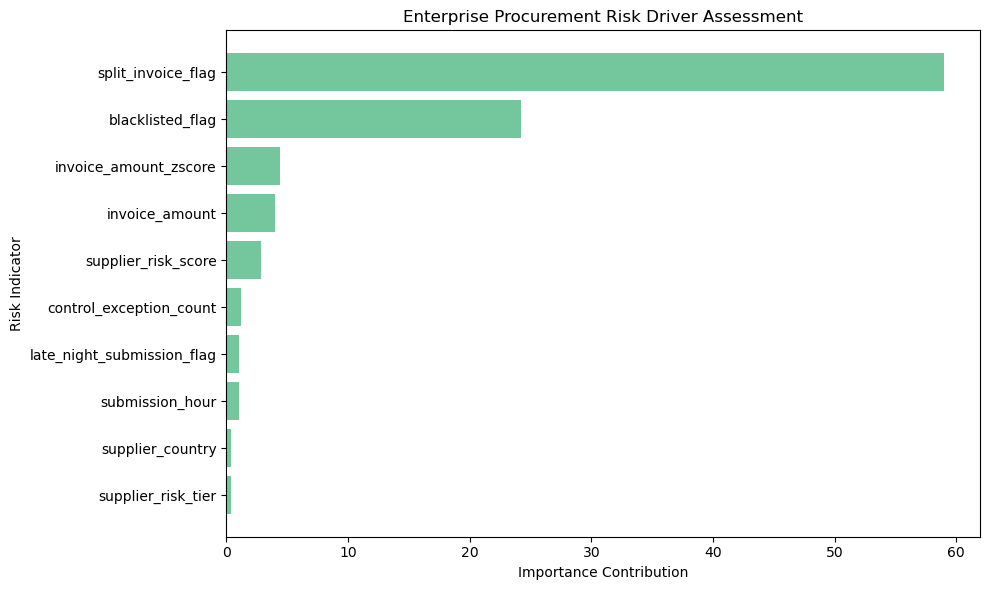

In [73]:
# Section 33: Visualize enterprise procurement risk drivers.

top_risk_drivers = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_risk_drivers["Risk Indicator"],
    top_risk_drivers["Importance Score"],
    color="#74C69D"
)

plt.title("Enterprise Procurement Risk Driver Assessment")
plt.xlabel("Importance Contribution")
plt.ylabel("Risk Indicator")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    BASE_DIR / "outputs" / "explainability" / "figures" / "enterprise_procurement_risk_driver_assessment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [74]:
# Section 34: Generate standardized procurement risk scores for all invoices.

audit_df["risk_probability"] = catboost_model.predict_proba(X)[:, 1]

audit_df["risk_score"] = (
    audit_df["risk_probability"] * 100
).round(2)

audit_df[[
    "invoice_id",
    "invoice_amount",
    "supplier_risk_score",
    "control_exception_count",
    "risk_probability",
    "risk_score",
    "is_fraud"
]].head()

,invoice_id,invoice_amount,supplier_risk_score,control_exception_count,risk_probability,risk_score,is_fraud
0,INV_0000000,3565.57,0.219,0,0.021123,2.11,0
1,INV_0000001,9871.78,0.083,0,0.019581,1.96,0
2,INV_0000002,8530.64,0.198,0,0.021413,2.14,0
3,INV_0000003,1378.52,0.382,1,0.981788,98.18,1
4,INV_0000004,2373.66,0.139,0,0.020539,2.05,0


In [75]:
# Section 35: Classify invoices into audit review priority tiers.

def assign_review_tier(score):
    if score >= 75:
        return "Critical Review Required"
    elif score >= 40:
        return "Enhanced Review"
    else:
        return "Routine Monitoring"

audit_df["audit_review_tier"] = audit_df["risk_score"].apply(assign_review_tier)

audit_df["audit_review_tier"].value_counts()

audit_review_tier
Routine Monitoring          236855
Critical Review Required     63102
Enhanced Review                 43
Name: count, dtype: int64

In [76]:
# Section 36: Review procurement risk score distribution.

audit_df["risk_score"].describe()

count    300000.000000
mean         22.138941
std          38.945697
min           0.510000
25%           1.930000
50%           2.070000
75%           2.430000
max          99.880000
Name: risk_score, dtype: float64

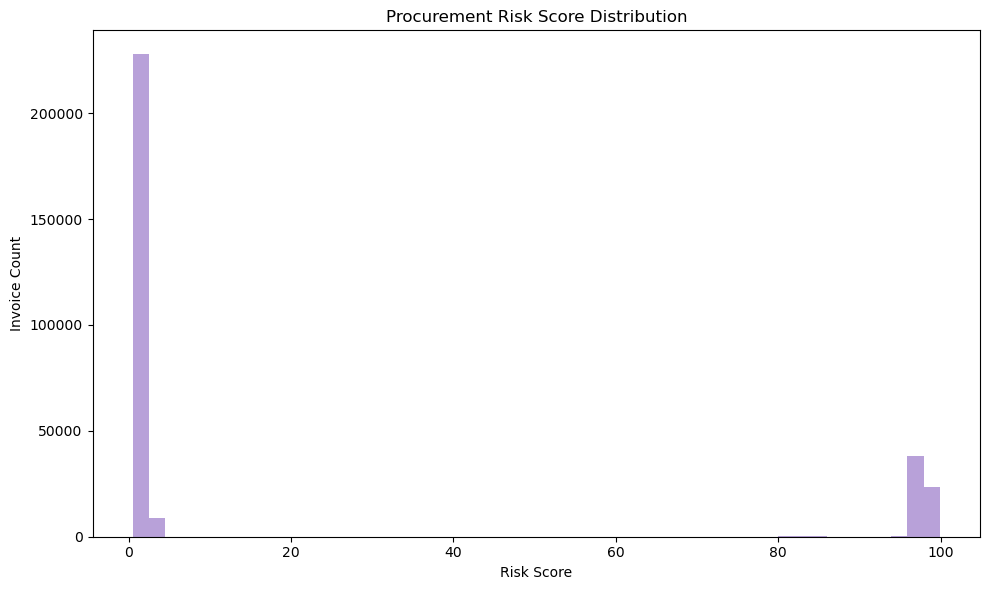

In [77]:
# Section 36: Visualize procurement risk score distribution.

plt.figure(figsize=(10,6))

plt.hist(
    audit_df["risk_score"],
    bins=50,
    color="#B8A1D9"
)

plt.title("Procurement Risk Score Distribution")
plt.xlabel("Risk Score")
plt.ylabel("Invoice Count")

plt.tight_layout()

plt.savefig(
    BASE_DIR / "outputs" / "explainability" / "figures" / "risk_score_distribution_assessment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [78]:
# Section 37: Create percentile-based audit review classifications.

q70 = audit_df["risk_score"].quantile(0.70)
q90 = audit_df["risk_score"].quantile(0.90)

print("70th Percentile:", q70)
print("90th Percentile:", q90)

70th Percentile: 2.26
90th Percentile: 97.83


In [79]:
# Section 38: Create risk-based audit prioritization framework.

def assign_audit_priority(score):
    if score >= q90:
        return "Critical Review Required"
    elif score >= q70:
        return "Enhanced Review"
    else:
        return "Routine Monitoring"

audit_df["audit_review_tier"] = (
    audit_df["risk_score"]
    .apply(assign_audit_priority)
)

audit_df["audit_review_tier"].value_counts()

audit_review_tier
Routine Monitoring          208904
Enhanced Review              60577
Critical Review Required     30519
Name: count, dtype: int64

In [80]:
# Section 38: Export AuditIQ Risk Intelligence Register.

risk_register = audit_df[
    [
        "invoice_id",
        "risk_score",
        "audit_review_tier",
        "supplier_risk_tier",
        "control_exception_count",
        "high_risk_supplier_flag",
        "invoice_amount",
        "supplier_risk_score",
        "is_fraud"
    ]
]

risk_register.to_csv(
    BASE_DIR / "outputs" / "risk_intelligence_register.csv",
    index=False
)

risk_register.head()

,invoice_id,risk_score,audit_review_tier,supplier_risk_tier,control_exception_count,high_risk_supplier_flag,invoice_amount,supplier_risk_score,is_fraud
0,INV_0000000,2.11,Routine Monitoring,Low Risk,0,0,3565.57,0.219,0
1,INV_0000001,1.96,Routine Monitoring,Low Risk,0,0,9871.78,0.083,0
2,INV_0000002,2.14,Routine Monitoring,Low Risk,0,0,8530.64,0.198,0
3,INV_0000003,98.18,Critical Review Required,Moderate Risk,1,0,1378.52,0.382,1
4,INV_0000004,2.05,Routine Monitoring,Low Risk,0,0,2373.66,0.139,0


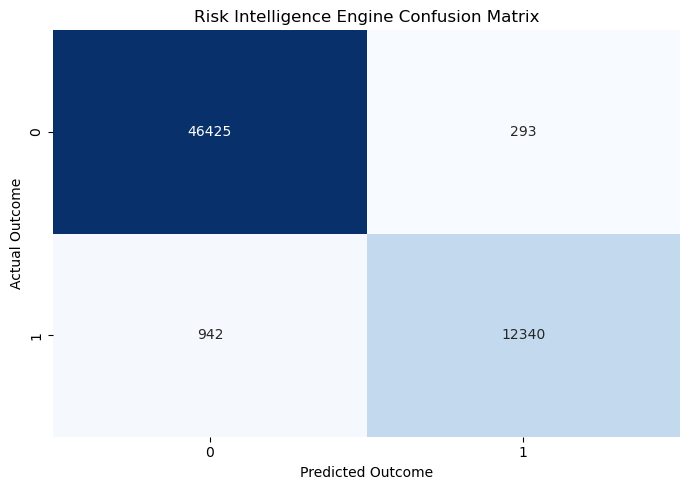

In [81]:
# Section 39: Visualize Risk Intelligence Engine classification outcomes.

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title("Risk Intelligence Engine Confusion Matrix")
plt.xlabel("Predicted Outcome")
plt.ylabel("Actual Outcome")

plt.tight_layout()

plt.savefig(
    BASE_DIR / "outputs" / "explainability" / "figures" / "confusion_matrix_assessment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

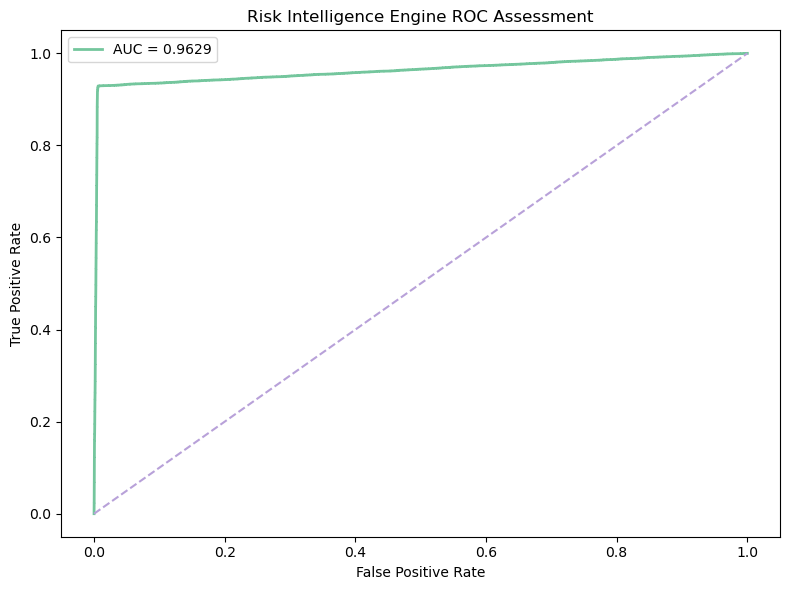

In [82]:
# Section 40: Visualize model discrimination performance.

from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {roc_auc:.4f}",
    color="#74C69D"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="#B8A1D9"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Risk Intelligence Engine ROC Assessment")

plt.legend()

plt.tight_layout()

plt.savefig(
    BASE_DIR / "outputs" / "explainability" / "figures" / "roc_performance_assessment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [84]:
# Section 41: Generate executive procurement risk portfolio summary.

executive_summary = pd.DataFrame({
    "Metric": [
        "Total Invoices Reviewed",
        "Elevated Risk Invoices",
        "Critical Review Population",
        "High-Risk Third Parties",
        "Invoices with Control Exceptions",
        "Confirmed Fraud Cases",
        "Risk Intelligence Engine AUC"
    ],
    "Value": [
        len(audit_df),
        (audit_df["risk_score"] >= q70).sum(),
        (audit_df["audit_review_tier"] == "Critical Review Required").sum(),
        audit_df["high_risk_supplier_flag"].sum(),
        (audit_df["control_exception_count"] > 0).sum(),
        audit_df["is_fraud"].sum(),
        round(roc_auc_score(y_test, y_prob), 4)
    ]
})

executive_summary

,Metric,Value
0,Total Invoices Reviewed,300000.0000
1,Elevated Risk Invoices,91096.0000
2,Critical Review Population,30519.0000
3,High-Risk Third Parties,4354.0000
4,Invoices with Control Exceptions,107175.0000
5,Confirmed Fraud Cases,66410.0000
6,Risk Intelligence Engine AUC,0.9629


In [85]:
# Section 41: Export executive audit portfolio summary.

executive_summary.to_csv(
    BASE_DIR / "outputs" / "executive_audit_portfolio_summary.csv",
    index=False
)

executive_summary

,Metric,Value
0,Total Invoices Reviewed,300000.0000
1,Elevated Risk Invoices,91096.0000
2,Critical Review Population,30519.0000
3,High-Risk Third Parties,4354.0000
4,Invoices with Control Exceptions,107175.0000
5,Confirmed Fraud Cases,66410.0000
6,Risk Intelligence Engine AUC,0.9629


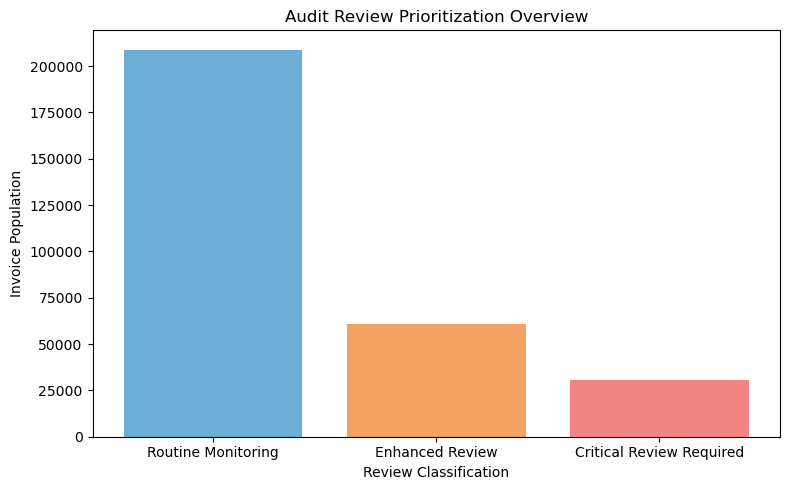

In [86]:
# Section 42: Visualize audit review prioritization populations.

review_summary = (
    audit_df["audit_review_tier"]
    .value_counts()
)

review_summary.to_csv(
    BASE_DIR / "outputs" / "eda" / "tables" / "audit_review_prioritization_summary.csv"
)

plt.figure(figsize=(8,5))

plt.bar(
    review_summary.index,
    review_summary.values,
    color=["#6BAED6", "#F4A261", "#F28482"]
)

plt.title("Audit Review Prioritization Overview")
plt.xlabel("Review Classification")
plt.ylabel("Invoice Population")

plt.tight_layout()

plt.savefig(
    BASE_DIR / "outputs" / "eda" / "figures" / "audit_review_prioritization_overview.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [87]:
# Section 43: Generate audit observations for elevated-risk transactions.

def generate_audit_observation(row):

    observations = []

    if row["split_invoice_flag"] == 1:
        observations.append("Invoice splitting behaviour detected")

    if row["duplicate_invoice_flag"] == 1:
        observations.append("Potential duplicate invoice identified")

    if row["high_risk_supplier_flag"] == 1:
        observations.append("High-risk third-party engagement identified")

    if row["late_night_submission_flag"] == 1:
        observations.append("Out-of-hours submission detected")

    if row["blacklisted_flag"] == 1:
        observations.append("Blacklisted supplier involvement identified")

    if len(observations) == 0:
        return "No significant audit observations"

    return "; ".join(observations)

audit_df["audit_observation"] = audit_df.apply(
    generate_audit_observation,
    axis=1
)

audit_df[[
    "invoice_id",
    "risk_score",
    "audit_observation"
]].head()

,invoice_id,risk_score,audit_observation
0,INV_0000000,2.11,No significant audit observations
1,INV_0000001,1.96,No significant audit observations
2,INV_0000002,2.14,No significant audit observations
3,INV_0000003,98.18,Invoice splitting behaviour detected
4,INV_0000004,2.05,No significant audit observations


In [88]:
# Section 44: Generate audit recommendations.

def generate_recommendation(row):

    if row["risk_score"] >= 97:
        return "Immediate investigation and supporting document review recommended."

    elif row["risk_score"] >= 80:
        return "Detailed transaction validation recommended."

    elif row["risk_score"] >= 50:
        return "Enhanced monitoring recommended."

    return "Routine monitoring."

audit_df["audit_recommendation"] = (
    audit_df.apply(generate_recommendation, axis=1)
)

In [89]:
# Section 45: Generate executive procurement risk KPIs.

executive_kpis = pd.DataFrame({

    "KPI": [

        "Total Procurement Transactions",

        "Elevated Risk Transactions",

        "Critical Review Population",

        "High-Risk Supplier Transactions",

        "Control Compliance Exceptions",

        "Confirmed Fraud Cases",

        "Risk Intelligence Engine AUC"

    ],

    "Value": [

        len(audit_df),

        (audit_df["risk_score"] >= q70).sum(),

        (audit_df["audit_review_tier"] == "Critical Review Required").sum(),

        audit_df["high_risk_supplier_flag"].sum(),

        (audit_df["control_exception_count"] > 0).sum(),

        audit_df["is_fraud"].sum(),

        round(roc_auc_score(y_test, y_prob), 4)

    ]
})

executive_kpis

,KPI,Value
0,Total Procurement Transactions,300000.0000
1,Elevated Risk Transactions,91096.0000
2,Critical Review Population,30519.0000
3,High-Risk Supplier Transactions,4354.0000
4,Control Compliance Exceptions,107175.0000
5,Confirmed Fraud Cases,66410.0000
6,Risk Intelligence Engine AUC,0.9629


In [90]:
# Section 45: Export executive KPI register.

executive_kpis.to_csv(
    BASE_DIR / "outputs" / "executive_kpi_register.csv",
    index=False
)

In [91]:
# Section 46: Create AuditIQ Executive Risk Register.

auditiq_register = audit_df[

    [

        "invoice_id",

        "invoice_amount",

        "supplier_risk_tier",

        "control_exception_count",

        "risk_score",

        "audit_review_tier",

        "audit_observation",

        "audit_recommendation",

        "is_fraud"

    ]

]

auditiq_register.head()

,invoice_id,invoice_amount,supplier_risk_tier,control_exception_count,risk_score,audit_review_tier,audit_observation,audit_recommendation,is_fraud
0,INV_0000000,3565.57,Low Risk,0,2.11,Routine Monitoring,No significant audit observations,Routine monitoring.,0
1,INV_0000001,9871.78,Low Risk,0,1.96,Routine Monitoring,No significant audit observations,Routine monitoring.,0
2,INV_0000002,8530.64,Low Risk,0,2.14,Routine Monitoring,No significant audit observations,Routine monitoring.,0
3,INV_0000003,1378.52,Moderate Risk,1,98.18,Critical Review Required,Invoice splitting behaviour detected,Immediate investigation and supporting documen...,1
4,INV_0000004,2373.66,Low Risk,0,2.05,Routine Monitoring,No significant audit observations,Routine monitoring.,0


In [92]:
# Section 46: Export AuditIQ Executive Risk Register.

auditiq_register.to_csv(
    BASE_DIR / "outputs" / "AuditIQ_Executive_Risk_Register.csv",
    index=False
)

In [93]:
# Section 47: Save Risk Intelligence Engine.

import joblib

joblib.dump(
    catboost_model,
    BASE_DIR / "outputs" / "AuditIQ_Risk_Engine.pkl"
)

print("AuditIQ Risk Engine exported successfully.")

AuditIQ Risk Engine exported successfully.


In [94]:
# Section 48: Create Excel dashboard export directory.

from pathlib import Path

excel_dir = BASE_DIR / "outputs" / "excel_dashboard"
excel_dir.mkdir(parents=True, exist_ok=True)

print("Excel dashboard directory created:", excel_dir)

Excel dashboard directory created: C:\Users\Pralisha Tripathy\Desktop\AuditIQ\outputs\excel_dashboard


In [96]:
# Section 49A: Verify Excel export dependencies.

import pandas as pd

print("Pandas Version:", pd.__version__)

Pandas Version: 2.2.2


In [97]:
!pip show pandas

Name: pandas
Version: 2.0.3
Summary: Powerful data structures for data analysis, time series, and statistics
Home-page: 
Author: 
Author-email: The Pandas Development Team <pandas-dev@python.org>
License: BSD 3-Clause License
        
        Copyright (c) 2008-2011, AQR Capital Management, LLC, Lambda Foundry, Inc. and PyData Development Team
        All rights reserved.
        
        Copyright (c) 2011-2023, Open source contributors.
        
        Redistribution and use in source and binary forms, with or without
        modification, are permitted provided that the following conditions are met:
        
        * Redistributions of source code must retain the above copyright notice, this
          list of conditions and the following disclaimer.
        
        * Redistributions in binary form must reproduce the above copyright notice,
          this list of conditions and the following disclaimer in the documentation
          and/or other materials provided with the distrib

In [98]:
# Section 49A: Check OpenPyXL availability.

!pip show openpyxl

Name: openpyxl
Version: 3.0.10
Summary: A Python library to read/write Excel 2010 xlsx/xlsm files
Home-page: https://openpyxl.readthedocs.io
Author: See AUTHORS
Author-email: charlie.clark@clark-consulting.eu
License: MIT
Location: c:\users\pralisha tripathy\anaconda3\lib\site-packages
Requires: et_xmlfile
Required-by: 


In [100]:
# Section 49C: Create Excel workbook using safe OpenPyXL export logic.

from openpyxl import Workbook
from openpyxl.utils.dataframe import dataframe_to_rows

excel_path = excel_dir / "AuditIQ_Phase2_Excel_Intelligence_Dashboard.xlsx"

def clean_excel_df(df):
    df_copy = df.copy()
    df_copy = df_copy.reset_index(drop=True)
    
    for col in df_copy.columns:
        if str(df_copy[col].dtype) == "category":
            df_copy[col] = df_copy[col].astype(str)
    
    return df_copy

sheets = {
    "Executive Summary": clean_excel_df(executive_kpis),
    "Risk Register": clean_excel_df(auditiq_register.head(50000)),
    "Risk Drivers": clean_excel_df(feature_importance),
    "Model Performance": clean_excel_df(metrics_summary)
}

wb = Workbook()
ws_default = wb.active
wb.remove(ws_default)

for sheet_name, df_sheet in sheets.items():
    ws = wb.create_sheet(title=sheet_name)
    
    for row in dataframe_to_rows(df_sheet, index=False, header=True):
        ws.append(row)

wb.save(excel_path)

print("AuditIQ Excel Intelligence Workbook created successfully.")
print(excel_path)

AuditIQ Excel Intelligence Workbook created successfully.
C:\Users\Pralisha Tripathy\Desktop\AuditIQ\outputs\excel_dashboard\AuditIQ_Phase2_Excel_Intelligence_Dashboard.xlsx


In [102]:
# Section 50A: Create AuditIQ dashboard directories.

from pathlib import Path

(Path(BASE_DIR / "outputs" / "excel_dashboard")).mkdir(
    parents=True,
    exist_ok=True
)

(Path(BASE_DIR / "outputs" / "excel_dashboard" / "charts")).mkdir(
    parents=True,
    exist_ok=True
)

(Path(BASE_DIR / "outputs" / "excel_dashboard" / "tables")).mkdir(
    parents=True,
    exist_ok=True
)

(Path(BASE_DIR / "outputs" / "excel_dashboard" / "workbook")).mkdir(
    parents=True,
    exist_ok=True
)

print("AuditIQ dashboard directories created successfully.")

AuditIQ dashboard directories created successfully.


In [103]:
# Section 50B: Verify dashboard directory structure.

import os

print(
    os.listdir(BASE_DIR / "outputs" / "excel_dashboard")
)

['AuditIQ_Phase2_Excel_Intelligence_Dashboard.xlsx', 'charts', 'tables', 'workbook']


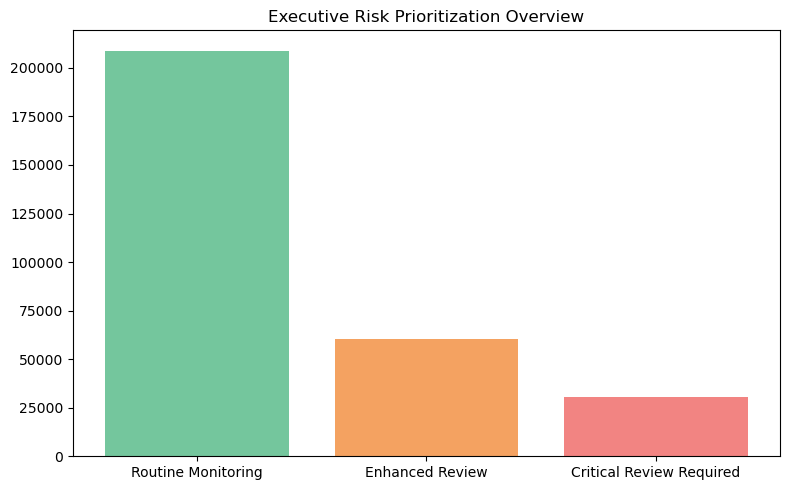

In [104]:
# Dashboard Asset 01

plt.figure(figsize=(8,5))

plt.bar(
    review_distribution["Review Tier"],
    review_distribution["Invoice Count"],
    color=[
        "#74C69D",
        "#F4A261",
        "#F28482"
    ]
)

plt.title(
    "Executive Risk Prioritization Overview"
)

plt.tight_layout()

plt.savefig(
    BASE_DIR /
    "outputs/excel_dashboard/charts/dashboard_asset_01_review_priority.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [105]:
# Section 50: Export dashboard-ready datasets.

review_distribution = (
    audit_df["audit_review_tier"]
    .value_counts()
    .reset_index()
)

review_distribution.columns = [
    "Review Tier",
    "Invoice Count"
]

review_distribution.to_csv(
    BASE_DIR / "outputs" / "excel_dashboard" / "tables" / "review_distribution.csv",
    index=False
)

review_distribution

,Review Tier,Invoice Count
0,Routine Monitoring,208904
1,Enhanced Review,60577
2,Critical Review Required,30519


In [106]:
# Section 51: Export critical review population.

critical_reviews = audit_df[
    audit_df["audit_review_tier"] ==
    "Critical Review Required"
]

critical_reviews.to_csv(
    BASE_DIR / "outputs" / "excel_dashboard" / "tables" / "critical_reviews.csv",
    index=False
)

print(critical_reviews.shape)

(30519, 35)


In [107]:
# Section 52: Export critical review population for investigation workspace.

critical_reviews = audit_df[
    audit_df["audit_review_tier"] == "Critical Review Required"
].copy()

critical_reviews.to_csv(
    BASE_DIR / "outputs" / "excel_dashboard" / "tables" / "critical_reviews.csv",
    index=False
)

print("Critical Review Population:", critical_reviews.shape)

Critical Review Population: (30519, 35)


In [108]:
# Section 53: Export executive KPI table for dashboard command center.

executive_kpis.to_csv(
    BASE_DIR / "outputs" / "excel_dashboard" / "tables" / "executive_kpis.csv",
    index=False
)

executive_kpis

,KPI,Value
0,Total Procurement Transactions,300000.0000
1,Elevated Risk Transactions,91096.0000
2,Critical Review Population,30519.0000
3,High-Risk Supplier Transactions,4354.0000
4,Control Compliance Exceptions,107175.0000
5,Confirmed Fraud Cases,66410.0000
6,Risk Intelligence Engine AUC,0.9629


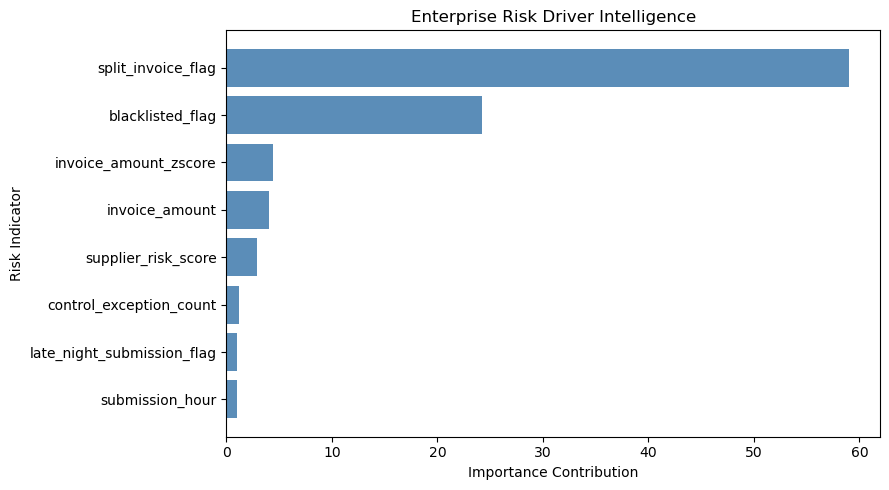

In [109]:
# Section 54: Create enterprise risk driver dashboard visual.

top_risk_drivers = feature_importance.head(8)

plt.figure(figsize=(9,5))

plt.barh(
    top_risk_drivers["Risk Indicator"],
    top_risk_drivers["Importance Score"],
    color="#5B8DB8"
)

plt.title("Enterprise Risk Driver Intelligence")
plt.xlabel("Importance Contribution")
plt.ylabel("Risk Indicator")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    BASE_DIR / "outputs" / "excel_dashboard" / "charts" / "dashboard_asset_02_risk_drivers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

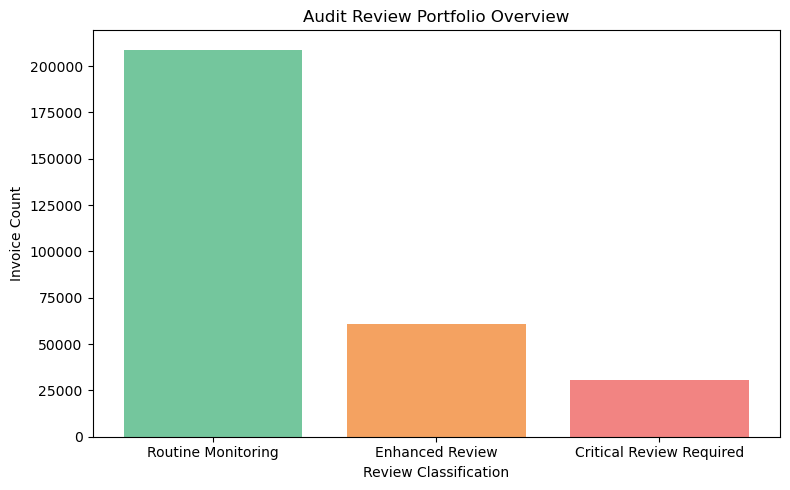

In [110]:
# Section 55: Create audit review portfolio dashboard visual.

review_distribution = (
    audit_df["audit_review_tier"]
    .value_counts()
    .reset_index()
)

review_distribution.columns = ["Audit Review Tier", "Invoice Count"]

plt.figure(figsize=(8,5))

plt.bar(
    review_distribution["Audit Review Tier"],
    review_distribution["Invoice Count"],
    color=["#74C69D", "#F4A261", "#F28482"]
)

plt.title("Audit Review Portfolio Overview")
plt.xlabel("Review Classification")
plt.ylabel("Invoice Count")

plt.tight_layout()

plt.savefig(
    BASE_DIR / "outputs" / "excel_dashboard" / "charts" / "dashboard_asset_03_review_portfolio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [112]:
# Section 56 Fixed: Create final AuditIQ Excel dashboard workbook using stable manual writing.

from openpyxl import Workbook
from openpyxl.drawing.image import Image
from openpyxl.styles import Font, PatternFill, Alignment

def write_df_to_sheet(ws, df):
    df = df.copy().reset_index(drop=True)

    for col in df.columns:
        if str(df[col].dtype) == "category":
            df[col] = df[col].astype(str)

    ws.append(list(df.columns))

    for row in df.itertuples(index=False, name=None):
        ws.append(list(row))

final_excel_path = (
    BASE_DIR / "outputs" / "excel_dashboard" / "workbook" /
    "AuditIQ_Excel_Intelligence_Dashboard.xlsx"
)

wb = Workbook()
ws = wb.active
ws.title = "Executive Dashboard"

ws["A1"] = "AuditIQ"
ws["A2"] = "AI-Powered Internal Audit & Procurement Risk Intelligence Dashboard"

ws["A1"].font = Font(size=24, bold=True, color="1F4E79")
ws["A2"].font = Font(size=12, color="666666")

write_df_to_sheet(ws, executive_kpis)

chart1 = Image(BASE_DIR / "outputs" / "excel_dashboard" / "charts" / "dashboard_asset_01_review_priority.png")
chart1.width = 480
chart1.height = 300
ws.add_image(chart1, "D4")

chart2 = Image(BASE_DIR / "outputs" / "excel_dashboard" / "charts" / "dashboard_asset_02_risk_drivers.png")
chart2.width = 480
chart2.height = 300
ws.add_image(chart2, "D20")

risk_ws = wb.create_sheet("Risk Register")
write_df_to_sheet(risk_ws, auditiq_register.head(50000))

drivers_ws = wb.create_sheet("Risk Drivers")
write_df_to_sheet(drivers_ws, feature_importance)

model_ws = wb.create_sheet("Model Performance")
write_df_to_sheet(model_ws, metrics_summary)

wb.save(final_excel_path)

print("Final AuditIQ Excel Dashboard created:")
print(final_excel_path)

Final AuditIQ Excel Dashboard created:
C:\Users\Pralisha Tripathy\Desktop\AuditIQ\outputs\excel_dashboard\workbook\AuditIQ_Excel_Intelligence_Dashboard.xlsx


In [113]:
# Section 57: Create Power BI master dataset.

powerbi_df = audit_df[[
    "invoice_id",
    "invoice_amount",
    "region",
    "invoice_type",
    "supplier_risk_tier",
    "supplier_risk_score",
    "control_exception_count",
    "high_risk_supplier_flag",
    "risk_score",
    "audit_review_tier",
    "audit_observation",
    "audit_recommendation",
    "is_fraud"
]].copy()

powerbi_df.head()

,invoice_id,invoice_amount,region,invoice_type,supplier_risk_tier,supplier_risk_score,control_exception_count,high_risk_supplier_flag,risk_score,audit_review_tier,audit_observation,audit_recommendation,is_fraud
0,INV_0000000,3565.57,North Carolina,GOODS,Low Risk,0.219,0,0,2.11,Routine Monitoring,No significant audit observations,Routine monitoring.,0
1,INV_0000001,9871.78,Arizona,SERVICES,Low Risk,0.083,0,0,1.96,Routine Monitoring,No significant audit observations,Routine monitoring.,0
2,INV_0000002,8530.64,Connecticut,SERVICES,Low Risk,0.198,0,0,2.14,Routine Monitoring,No significant audit observations,Routine monitoring.,0
3,INV_0000003,1378.52,Pennsylvania,GOODS,Moderate Risk,0.382,1,0,98.18,Critical Review Required,Invoice splitting behaviour detected,Immediate investigation and supporting documen...,1
4,INV_0000004,2373.66,Louisiana,GOODS,Low Risk,0.139,0,0,2.05,Routine Monitoring,No significant audit observations,Routine monitoring.,0


In [114]:
# Section 57: Export Power BI master dataset.

powerbi_df.to_csv(
    BASE_DIR / "outputs" / "AuditIQ_PowerBI_Master.csv",
    index=False
)

print("Power BI dataset exported successfully.")

Power BI dataset exported successfully.


In [119]:
# Section 58: Define anomaly detection feature set.

anomaly_features = [
    "invoice_amount",
    "submission_hour",
    "supplier_age_days",
    "supplier_risk_score",
    "annual_budget",
    "supplier_invoice_count_30d",
    "supplier_avg_amount_90d",
    "invoice_amount_zscore",
    "duplicate_invoice_flag",
    "split_invoice_flag",
    "late_night_submission_flag",
    "invoice_supplier_ratio",
    "budget_impact_ratio",
    "control_exception_count",
    "high_risk_supplier_flag"
]

anomaly_X = audit_df[anomaly_features].copy()

print("Anomaly Detection Matrix:", anomaly_X.shape)

Anomaly Detection Matrix: (300000, 15)


In [120]:
# Section 59: Scale anomaly detection features for Isolation Forest.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

anomaly_X_scaled = scaler.fit_transform(anomaly_X)

print("Scaled Anomaly Matrix:", anomaly_X_scaled.shape)

Scaled Anomaly Matrix: (300000, 15)


In [121]:
# Section 60: Train Isolation Forest anomaly detection engine.

from sklearn.ensemble import IsolationForest

isolation_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)

isolation_forest.fit(anomaly_X_scaled)

print("Isolation Forest training completed.")

Isolation Forest training completed.


In [122]:
# Section 61: Generate anomaly scores and anomaly flags.

audit_df["anomaly_prediction"] = isolation_forest.predict(anomaly_X_scaled)

audit_df["anomaly_flag"] = audit_df["anomaly_prediction"].map({
    1: 0,
    -1: 1
})

audit_df["anomaly_score"] = -isolation_forest.decision_function(anomaly_X_scaled)

audit_df[["invoice_id", "anomaly_score", "anomaly_flag", "is_fraud"]].head()

,invoice_id,anomaly_score,anomaly_flag,is_fraud
0,INV_0000000,-0.156834,0,0
1,INV_0000001,-0.099479,0,0
2,INV_0000002,-0.131267,0,0
3,INV_0000003,-0.051778,0,1
4,INV_0000004,-0.171140,0,0


In [123]:
# Section 61: Review anomaly detection output distribution.

audit_df["anomaly_flag"].value_counts()

anomaly_flag
0    285000
1     15000
Name: count, dtype: int64

In [124]:
# Section 62: Compare fraud rates between normal and anomalous populations.

anomaly_validation = pd.crosstab(
    audit_df["anomaly_flag"],
    audit_df["is_fraud"],
    normalize="index"
) * 100

anomaly_validation

is_fraud,0,1
anomaly_flag,,
0,80.839649,19.160351
1,21.313333,78.686667


In [125]:
# Section 62: Save anomaly validation results.

anomaly_validation.to_csv(
    BASE_DIR / "outputs" / "explainability" / "tables" /
    "isolation_forest_anomaly_validation.csv"
)

anomaly_validation

is_fraud,0,1
anomaly_flag,,
0,80.839649,19.160351
1,21.313333,78.686667


In [126]:
# Section 63: Create anomaly alert indicator.

audit_df["anomaly_alert"] = audit_df["anomaly_flag"].map({
    0: "Normal Behaviour",
    1: "Anomalous Behaviour"
})

audit_df["anomaly_alert"].value_counts()

anomaly_alert
Normal Behaviour       285000
Anomalous Behaviour     15000
Name: count, dtype: int64

In [127]:
# Section 64: Create combined risk intelligence indicator.

audit_df["high_risk_and_anomalous"] = (
    (audit_df["risk_score"] >= 90)
    &
    (audit_df["anomaly_flag"] == 1)
).astype(int)

audit_df["high_risk_and_anomalous"].value_counts()

high_risk_and_anomalous
0    288397
1     11603
Name: count, dtype: int64

In [128]:
# Section 64: Validate combined risk intelligence performance.

combined_validation = pd.crosstab(
    audit_df["high_risk_and_anomalous"],
    audit_df["is_fraud"],
    normalize="index"
) * 100

combined_validation

is_fraud,0,1
high_risk_and_anomalous,,
0,80.913463,19.086537
1,2.051194,97.948806


In [129]:
# Section 65: Create priority investigation indicator.

audit_df["priority_investigation_flag"] = (
    (audit_df["risk_score"] >= 90)
    &
    (audit_df["anomaly_flag"] == 1)
).astype(int)

audit_df["priority_investigation_flag"].value_counts()

priority_investigation_flag
0    288397
1     11603
Name: count, dtype: int64

In [130]:
# Section 65: Create investigation status label.

audit_df["investigation_priority"] = (
    audit_df["priority_investigation_flag"]
    .map({
        1: "Immediate Investigation",
        0: "Standard Monitoring"
    })
)

audit_df["investigation_priority"].value_counts()

investigation_priority
Standard Monitoring        288397
Immediate Investigation     11603
Name: count, dtype: int64

In [131]:
# Section 66: Save audit intelligence indicators.

audit_df.to_csv(
    BASE_DIR / "outputs" / "auditiq_master_with_anomaly_detection.csv",
    index=False
)

print("AuditIQ master dataset updated.")

AuditIQ master dataset updated.


In [132]:
# Section 67: Review immediate investigation population.

priority_cases = audit_df[
    audit_df["investigation_priority"] == "Immediate Investigation"
]

priority_cases[[
    "invoice_id",
    "risk_score",
    "anomaly_score",
    "investigation_priority",
    "is_fraud"
]].head(10)

,invoice_id,risk_score,anomaly_score,investigation_priority,is_fraud
19,INV_0000019,97.74,0.015611,Immediate Investigation,1
42,INV_0000042,95.48,0.003682,Immediate Investigation,1
50,INV_0000050,99.32,0.020355,Immediate Investigation,1
65,INV_0000065,97.55,0.033313,Immediate Investigation,1
66,INV_0000066,98.11,0.075710,Immediate Investigation,1
77,INV_0000077,97.79,0.012834,Immediate Investigation,1
107,INV_0000107,98.24,0.010631,Immediate Investigation,1
117,INV_0000117,97.31,0.032062,Immediate Investigation,1
160,INV_0000160,97.20,0.055148,Immediate Investigation,1
190,INV_0000190,99.34,0.040565,Immediate Investigation,1


In [133]:
# Section 68: Check SHAP dependencies.

import numba

print("Numba Version:", numba.__version__)

SystemError: initialization of _internal failed without raising an exception

In [134]:
# Section 68: Check SHAP version.

import importlib.metadata

print(
    "SHAP Version:",
    importlib.metadata.version("shap")
)

SHAP Version: 0.49.1


In [135]:
import joblib

joblib.dump(catboost_model, "catboost_risk_engine.pkl")
joblib.dump(isolation_forest, "isolation_forest_engine.pkl")

print("Models saved successfully.")

Models saved successfully.


In [1]:
# Section 69: Install PostgreSQL connector.

!pip install psycopg2-binary sqlalchemy

     ---------------------------------------- 2.8/2.8 MB 4.0 MB/s eta 0:00:00


In [4]:
DB_PASSWORD = "pralisha"

In [6]:
# Section 70: Create PostgreSQL connection.

from sqlalchemy import create_engine

DB_USER = "postgres"
DB_PASSWORD = "YOUR_PASSWORD"
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "AuditIQ_DB"

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

print("AuditIQ database connection established.")

AuditIQ database connection established.


In [8]:
import psycopg2

conn = psycopg2.connect(
    host="localhost",
    database="AuditIQ_DB",
    user="postgres",
    password="pralisha"
)

print("Connected successfully!")

Connected successfully!


In [9]:
# Section 72: Load AuditIQ master dataset into PostgreSQL.

import pandas as pd
from pathlib import Path

BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

audit_master_path = BASE_DIR / "outputs" / "auditiq_master_with_anomaly_detection.csv"

audit_master = pd.read_csv(audit_master_path)

print("Dataset Loaded:", audit_master.shape)

Dataset Loaded: (300000, 42)


In [11]:
# Recreate SQLAlchemy engine with the correct PostgreSQL password.

from sqlalchemy import create_engine
from urllib.parse import quote_plus

DB_USER = "postgres"
DB_PASSWORD = quote_plus("pralisha")
DB_HOST = "127.0.0.1"
DB_PORT = "5432"
DB_NAME = "AuditIQ_DB"

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

print("Engine recreated.")

Engine recreated.


In [12]:
pd.read_sql("SELECT current_database();", engine)

,current_database
0,AuditIQ_DB


In [13]:
audit_master.to_sql(
    "audit_risk_register",
    engine,
    if_exists="replace",
    index=False,
    chunksize=10000
)

30000

In [14]:
pd.read_sql(
    "SELECT COUNT(*) AS total_records FROM audit_risk_register;",
    engine
)

,total_records
0,300000


In [15]:
pd.read_sql(
    "SELECT * FROM audit_risk_register LIMIT 5;",
    engine
)

,invoice_id,supplier_id,department_id,invoice_date,invoice_amount,currency,payment_terms,invoice_type,submission_hour,supplier_country,...,audit_review_tier,audit_observation,audit_recommendation,anomaly_prediction,anomaly_flag,anomaly_score,anomaly_alert,high_risk_and_anomalous,priority_investigation_flag,investigation_priority
0,INV_0000000,7316ce64-2a14-4a96-9b0c-62eb27c8fc6c,DPT_025,2023-04-18,3565.57,ZAR,NET60,GOODS,18,CA,...,Routine Monitoring,No significant audit observations,Routine monitoring.,1,0,-0.156834,Normal Behaviour,0,0,Standard Monitoring
1,INV_0000001,7428a656-b3ee-4d3b-9a10-412954aebd1b,DPT_010,2023-10-08,9871.78,ZAR,NET30,SERVICES,6,SV,...,Routine Monitoring,No significant audit observations,Routine monitoring.,1,0,-0.099479,Normal Behaviour,0,0,Standard Monitoring
2,INV_0000002,7b0ccad9-eee1-4cae-b02e-21aa352b6ec8,DPT_041,2023-09-24,8530.64,ZAR,NET60,SERVICES,23,MR,...,Routine Monitoring,No significant audit observations,Routine monitoring.,1,0,-0.131267,Normal Behaviour,0,0,Standard Monitoring
3,INV_0000003,1c6345ab-6e0e-41e8-985d-3f861d2324e6,DPT_015,2023-10-15,1378.52,ZAR,NET30,GOODS,7,SR,...,Critical Review Required,Invoice splitting behaviour detected,Immediate investigation and supporting documen...,1,0,-0.051778,Normal Behaviour,0,0,Standard Monitoring
4,INV_0000004,22d839d3-33e4-4986-b18c-ccdc131eb723,DPT_039,2023-06-07,2373.66,ZAR,NET30,GOODS,12,TV,...,Routine Monitoring,No significant audit observations,Routine monitoring.,1,0,-0.171140,Normal Behaviour,0,0,Standard Monitoring


In [16]:
pd.read_sql(
    """
    SELECT investigation_priority, COUNT(*) AS invoice_count
    FROM audit_risk_register
    GROUP BY investigation_priority;
    """,
    engine
)

,investigation_priority,invoice_count
0,Immediate Investigation,11603
1,Standard Monitoring,288397


In [17]:
pd.read_sql(
    """
    SELECT audit_review_tier, COUNT(*) AS invoice_count
    FROM audit_risk_register
    GROUP BY audit_review_tier
    ORDER BY invoice_count DESC;
    """,
    engine
)

,audit_review_tier,invoice_count
0,Routine Monitoring,208904
1,Enhanced Review,60577
2,Critical Review Required,30519


In [21]:
catboost_model.feature_names_

NameError: name 'catboost_model' is not defined

In [22]:
import joblib
from pathlib import Path

BASE_DIR = Path(r"C:\Users\Pralisha Tripathy\Desktop\AuditIQ")

catboost_model = joblib.load(
    BASE_DIR / "catboost_risk_engine.pkl"
)

print(type(catboost_model))

<class 'catboost.core.CatBoostClassifier'>


In [23]:
catboost_model.feature_names_

['invoice_amount',
 'currency',
 'payment_terms',
 'invoice_type',
 'submission_hour',
 'supplier_country',
 'supplier_age_days',
 'supplier_risk_score',
 'blacklisted_flag',
 'region',
 'annual_budget',
 'supplier_invoice_count_30d',
 'supplier_avg_amount_90d',
 'invoice_amount_zscore',
 'duplicate_invoice_flag',
 'split_invoice_flag',
 'late_night_submission_flag',
 'invoice_supplier_ratio',
 'budget_impact_ratio',
 'control_exception_count',
 'supplier_risk_tier',
 'high_risk_supplier_flag']